# 项目 5：使用聚类进行客户细分

**项目目标：** 使用无监督机器学习识别商场客户数据中的不同人群。通过从收入、年龄和消费行为等维度对客户进行分群，我们可以把原始客户记录转化为清晰的用户画像，并为营销团队提供可执行的策略建议。

### 本项目将覆盖的核心概念：

1. **无监督学习：** 理解没有标签的数据如何被建模。
2. **聚类基础与 K-Means：** 学习 K-Means 如何把相似的数据点归为一组。
3. **肘部法则：** 使用 WCSS / inertia 选择合理的聚类数量。
4. **多维探索性数据分析：** 用 2D 和 3D 可视化观察客户特征之间的关系。
5. **多个客户细分模型：** 对比基于收入和基于年龄的分群结果。
6. **层次聚类：** 使用树状图从另一种角度理解聚类结构。
7. **数据驱动的客户画像：** 将聚类统计结果转化为业务建议。

### 理论概念：什么是无监督学习？

在前面的项目中，我们主要使用的是**监督学习**。这类数据集通常包含一个已知的目标变量，例如 `SalePrice`、`Survived` 或疾病标签。模型要学习输入特征和目标答案之间的关系。

**无监督学习**不同。数据集中没有给定目标标签，模型的任务不是预测一个已知答案，而是从数据本身发现隐藏的结构、模式和关系。

**聚类**是最常见的无监督学习任务之一。它会把相似的数据点分到同一组，让同一簇内的客户尽可能相似，而不同簇之间的客户尽可能不同。

### 第 1 步：准备环境 - 导入库并加载数据

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import scipy.cluster.hierarchy as sch

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# 设置绘图风格
sns.set_style('whitegrid')

### 理论概念：K-Means 是如何工作的？

K-Means 是一种迭代式聚类算法。可以把它想象成把一堆混合物品分到不同盒子里：

1. **选择 `k`：** 先决定要分成多少组。
2. **初始化质心：** 为每一组选择一个初始中心点。
3. **分配样本：** 把每个数据点分配给距离最近的质心。
4. **更新质心：** 用当前簇内所有样本的平均位置重新计算质心。
5. **重复迭代：** 继续分配和更新，直到质心基本不再移动。

算法结束后，每个客户都会被分到一个簇中，每个簇的质心代表该类客户的典型特征。

In [4]:
# 从课程数据仓库加载数据集
#!git clone "https://github.com/HarshvardhanSingh-13/Datasets"
df = pd.read_csv('../Datasets/Mall Dataset/Mall_Customers.csv')

print("数据集加载成功。")
print(f"数据形状: {df.shape}")
df.head()

数据集加载成功。
数据形状: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


### 第 2 步：深入探索性数据分析（EDA）

在进行聚类之前，我们需要先理解数据特征及其关系。EDA 可以帮助我们判断哪些维度更适合用来做客户细分。

In [5]:
# 查看基础信息和描述性统计
print("数据集信息:")
df.info()

# CustomerID 只是唯一编号，不适合用于聚类，因此删除
df.drop('CustomerID', axis=1, inplace=True)

print("\n描述性统计:")
print(df.describe())

数据集信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB

描述性统计:
              Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000          200.000000              200.000000
mean    38.850000           60.560000               50.200000
std     13.969007           26.264721               25.823522
min     18.000000           15.000000                1.000000
25%     28.750000           41.500000               34.750000
50%     36.000000           61.500000               50.000000
75%     49.000000           78.00

#### 2.1 单变量分析：特征分布

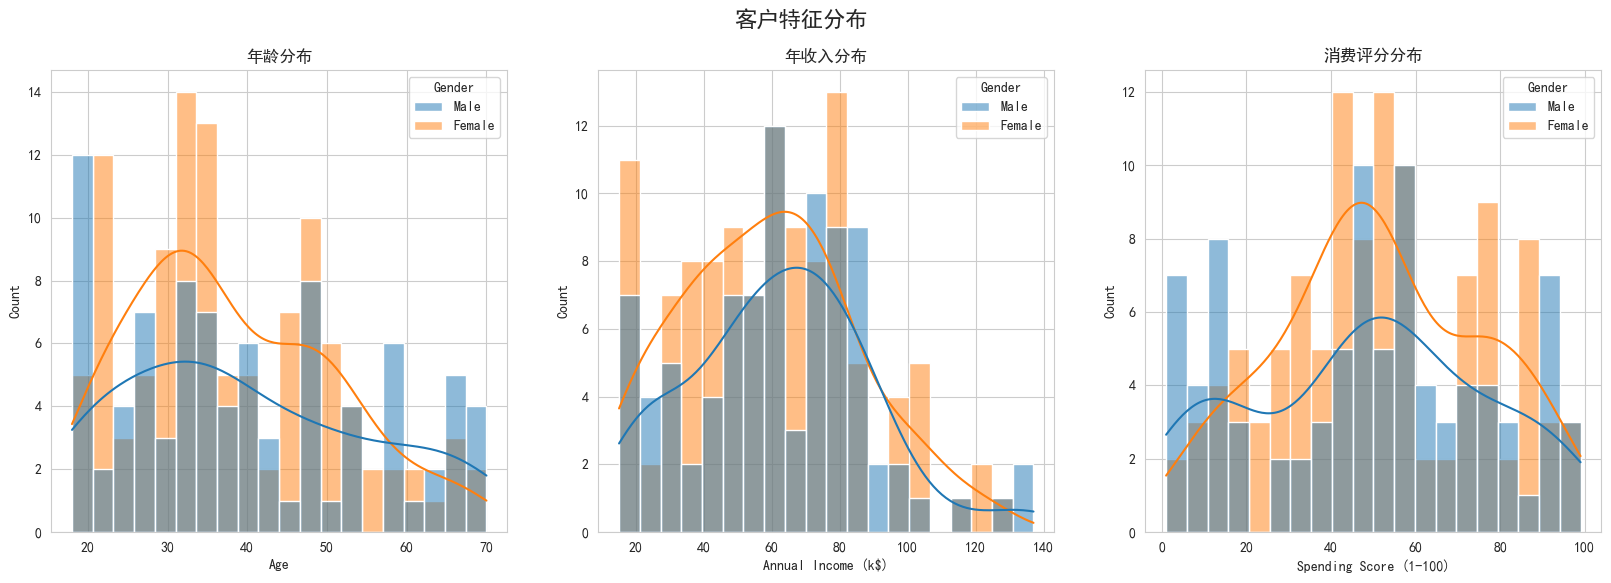

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
#中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置中文字体为黑体
plt.rcParams['axes.unicode_minus'] = False  # 正常显示负号

fig.suptitle('客户特征分布', fontsize=16)

sns.histplot(ax=axes[0], data=df, x='Age', kde=True, bins=20, hue='Gender').set_title('年龄分布')
sns.histplot(ax=axes[1], data=df, x='Annual Income (k$)', kde=True, bins=20, hue='Gender').set_title('年收入分布')
sns.histplot(ax=axes[2], data=df, x='Spending Score (1-100)', kde=True, bins=20, hue='Gender').set_title('消费评分分布')

plt.show()

#### 2.2 双变量分析：观察特征关系

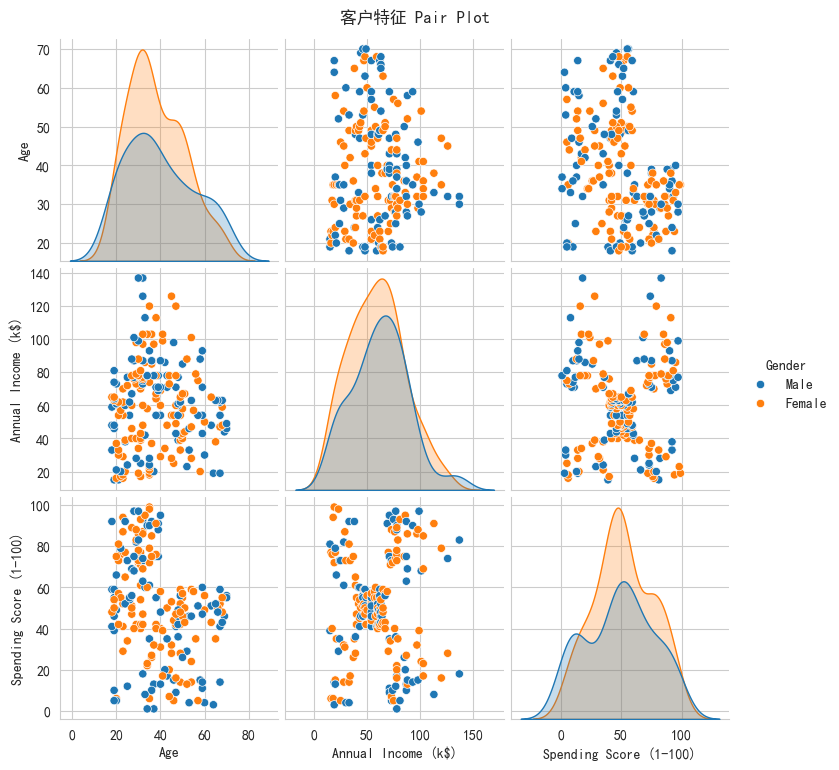

In [10]:
# 使用 pairplot 同时观察数值特征之间的关系
sns.pairplot(df, vars=['Age', 'Annual Income (k$)', 'Spending Score (1-100)'], hue='Gender', diag_kind='kde')
plt.suptitle('客户特征 Pair Plot', y=1.02)
plt.show()

**从 Pair Plot 得到的关键洞察：**

- **`Annual Income (k$)` 与 `Spending Score (1-100)`** 的散点图呈现出最清晰的团块结构，因此非常适合作为主要聚类特征。
- **`Age` 与 `Spending Score (1-100)`** 也存在一定模式，尤其可以看到年轻高消费客户，但分隔没有收入-消费组合那么明显。
- `Gender` 不是强分隔特征，因为男性和女性的分布大体重叠。

#### 2.3 三维可视化

接下来我们同时观察年龄、年收入和消费评分三个维度。三维图可以帮助我们判断二维图中看到的结构在加入另一个变量后是否仍然成立。

In [11]:
fig = px.scatter_3d(df,
                    x='Annual Income (k$)',
                    y='Spending Score (1-100)',
                    z='Age',
                    color='Gender',
                    title='客户数据三维视图')
fig.show()

### 第 3 步：客户细分模型 1 - 年收入与消费评分

这是我们的主要客户细分模型，因为 EDA 表明年收入和消费评分之间存在非常清晰的聚类结构。

## 理论概念：肘部法则

如何为 K-Means 选择最佳的聚类数量 `k`？**肘部法则**是一个常用且直观的方法。

对于每个可能的 `k`，我们计算 **WCSS**，即簇内平方和。在 scikit-learn 中，它也叫 **inertia**。WCSS 衡量样本点到所属簇质心的距离总和，数值越低表示簇越紧凑。

随着 `k` 增加，WCSS 一定会下降。但我们关注的是：从哪一个点开始，继续增加簇数量带来的改善明显变小。曲线中这个像“手肘”一样的拐点，通常就是一个较合理的 `k`。

### K-Means 的初始化选项

`init` 参数控制初始质心的选择方式：

- **`k-means++`：** 默认且推荐的方式。它会让初始质心尽量分散，通常能得到更稳定的结果。
- **`random`：** 随机选择样本作为初始质心。实现简单，但结果可能不够稳定。
- **自定义 NumPy 数组：** 当你有先验知识或需要复现实验时，可以手动指定初始质心坐标。

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it 

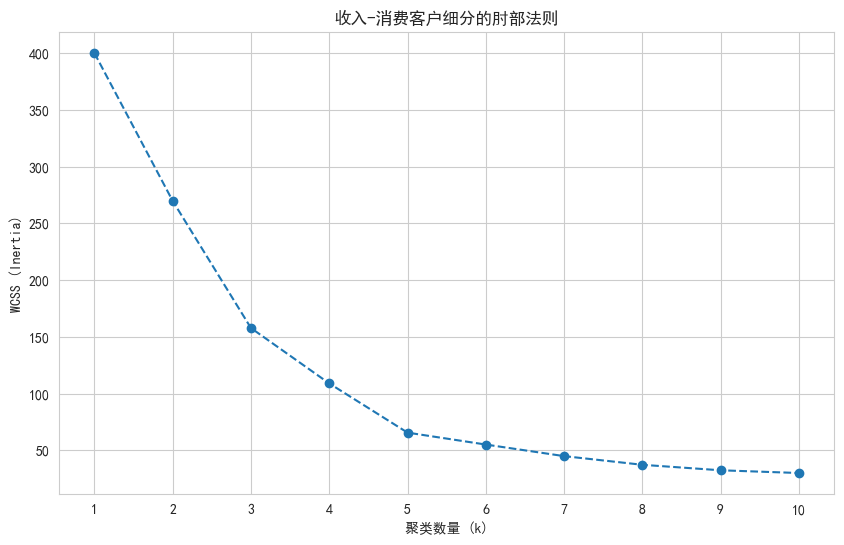

In [12]:
# 1. 选择并标准化特征
X1 = df[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler1 = StandardScaler()
X1_scaled = scaler1.fit_transform(X1)

# 2. 使用肘部法则寻找合适的 k
wcss1 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X1_scaled)
    wcss1.append(kmeans.inertia_)

# 3. 绘制肘部曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss1, marker='o', linestyle='--')
plt.title('收入-消费客户细分的肘部法则')
plt.xlabel('聚类数量 (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

### 如何理解 WCSS

可以把每个簇看作一个小组，把质心看作这个小组的中心。WCSS 会把每个成员到组中心的距离平方后加总。

**低 WCSS** 表示组内成员离中心较近，簇更紧凑。**高 WCSS** 表示组内成员更分散，簇的边界不够清晰。

K-Means 的目标就是尽量降低 WCSS。肘部法则正是利用这一点，帮助我们选择有解释价值的 `k`。

**观察：** 曲线的肘部大约出现在 **k = 5**。在 5 个簇之前，WCSS 快速下降；之后曲线变得平缓。这也与前面散点图中看到的结构一致。

In [13]:
# 构建并训练最终模型
kmeans1 = KMeans(n_clusters=5, init='k-means++', random_state=42, n_init=10)
df['Income_Cluster'] = kmeans1.fit_predict(X1_scaled)

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



#### 3.1 可视化并解释基于收入的客户细分

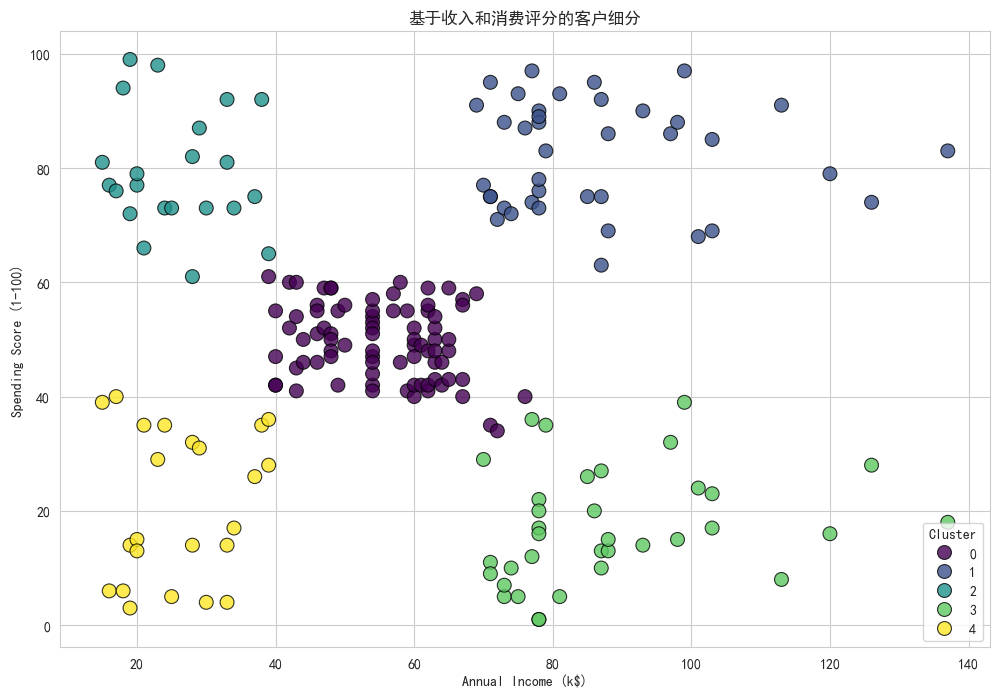

In [14]:
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)',
                hue='Income_Cluster', palette='viridis', s=100, alpha=0.8, edgecolor='black')
plt.title('基于收入和消费评分的客户细分')
plt.legend(title='Cluster')
plt.show()

In [16]:
# 定量分析每个客户画像
cluster_profiles1 = df.groupby('Income_Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(2)
cluster_profiles1['Size'] = df['Income_Cluster'].value_counts()
print("--- 基于收入的聚类画像 ---")
cluster_profiles1

--- 基于收入的聚类画像 ---


,Age,Annual Income (k$),Spending Score (1-100),Size
Income_Cluster,,,,
0,42.72,55.30,49.52,81
1,32.69,86.54,82.13,39
2,25.27,25.73,79.36,22
3,41.11,88.20,17.11,35
4,45.22,26.30,20.91,23


#### 3.2 基于收入的客户画像与营销策略

结合每个簇的统计画像，我们可以定义以下客户人群：

- **Cluster 0：谨慎型高收入客户** - 收入较高但消费评分较低。可以尝试高端价值组合、保障服务或会员权益。
- **Cluster 1：标准客户** - 收入和消费均处于平均水平。这通常是核心客户群，适合通用型营销活动。
- **Cluster 2：预算敏感型客户** - 收入和消费都较低。可能更关注价格，适合折扣和促销。
- **Cluster 3：高价值目标客户** - 收入高且消费高。适合 VIP 项目、精品推荐和高端活动。
- **Cluster 4：热情消费型客户** - 收入较低但消费较高。可能更年轻、追求潮流，适合新品和趋势类营销。

### 第 4 步：客户细分模型 2 - 年龄与消费评分

接下来我们建立第二个细分模型，从年龄角度观察客户行为。

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it 

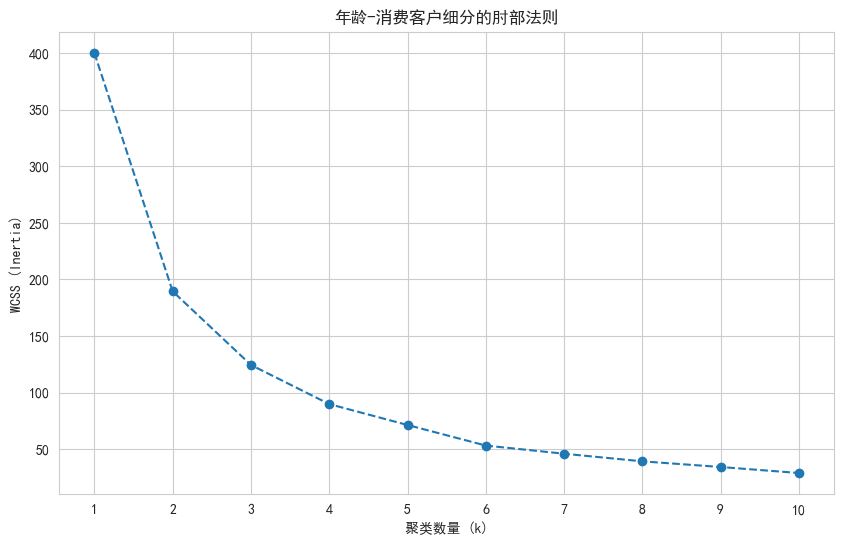

In [17]:
# 1. 选择并标准化特征
X2 = df[['Age', 'Spending Score (1-100)']]
scaler2 = StandardScaler()
X2_scaled = scaler2.fit_transform(X2)

# 2. 使用肘部法则寻找合适的 k
wcss2 = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X2_scaled)
    wcss2.append(kmeans.inertia_)

# 3. 绘制肘部曲线
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss2, marker='o', linestyle='--')
plt.title('年龄-消费客户细分的肘部法则')
plt.xlabel('聚类数量 (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, 11))
plt.show()

**观察：** 在这个特征空间中，肘部没有那么明显，但 **k = 4** 是一个相对合理且容易解释的选择。

d:\app\anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.



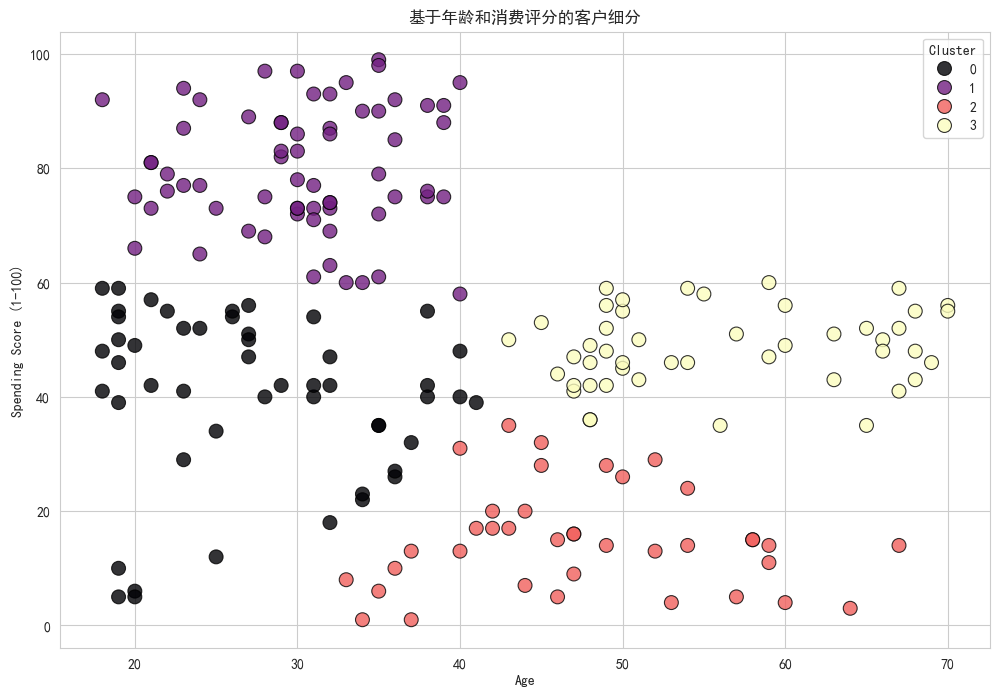

In [18]:
# 构建并训练基于年龄的最终模型
kmeans2 = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
df['Age_Cluster'] = kmeans2.fit_predict(X2_scaled)

# 可视化新的聚类结果
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df, x='Age', y='Spending Score (1-100)',
                hue='Age_Cluster', palette='magma', s=100, alpha=0.8, edgecolor='black')
plt.title('基于年龄和消费评分的客户细分')
plt.legend(title='Cluster')
plt.show()

#### 4.1 解释基于年龄的客户细分

这个模型提供了另一种客户视角：

- **年轻高消费客户：** 40 岁以下且消费评分较高。
- **年轻低到中等消费客户：** 年轻但消费评分偏低或中等。
- **年长平均消费客户：** 40 岁以上且消费评分中等。
- **年长低消费客户：** 年龄较大且消费评分很低。

### 第 5 步：替代方法 - 层次聚类

为了让分析更完整，我们简要比较 K-Means 与另一种聚类方法。

#### 理论概念：层次聚类与树状图

层次聚类会构建一个树状的聚类结构。与 K-Means 不同，它不要求我们一开始就指定 `k`，而是通过**树状图**观察样本如何逐步合并成更大的组。

判断聚类数量时，可以寻找较长且没有被横向合并线穿过的竖直距离。在这个位置画一条水平线，穿过的主要分支数量就可以作为候选聚类数。

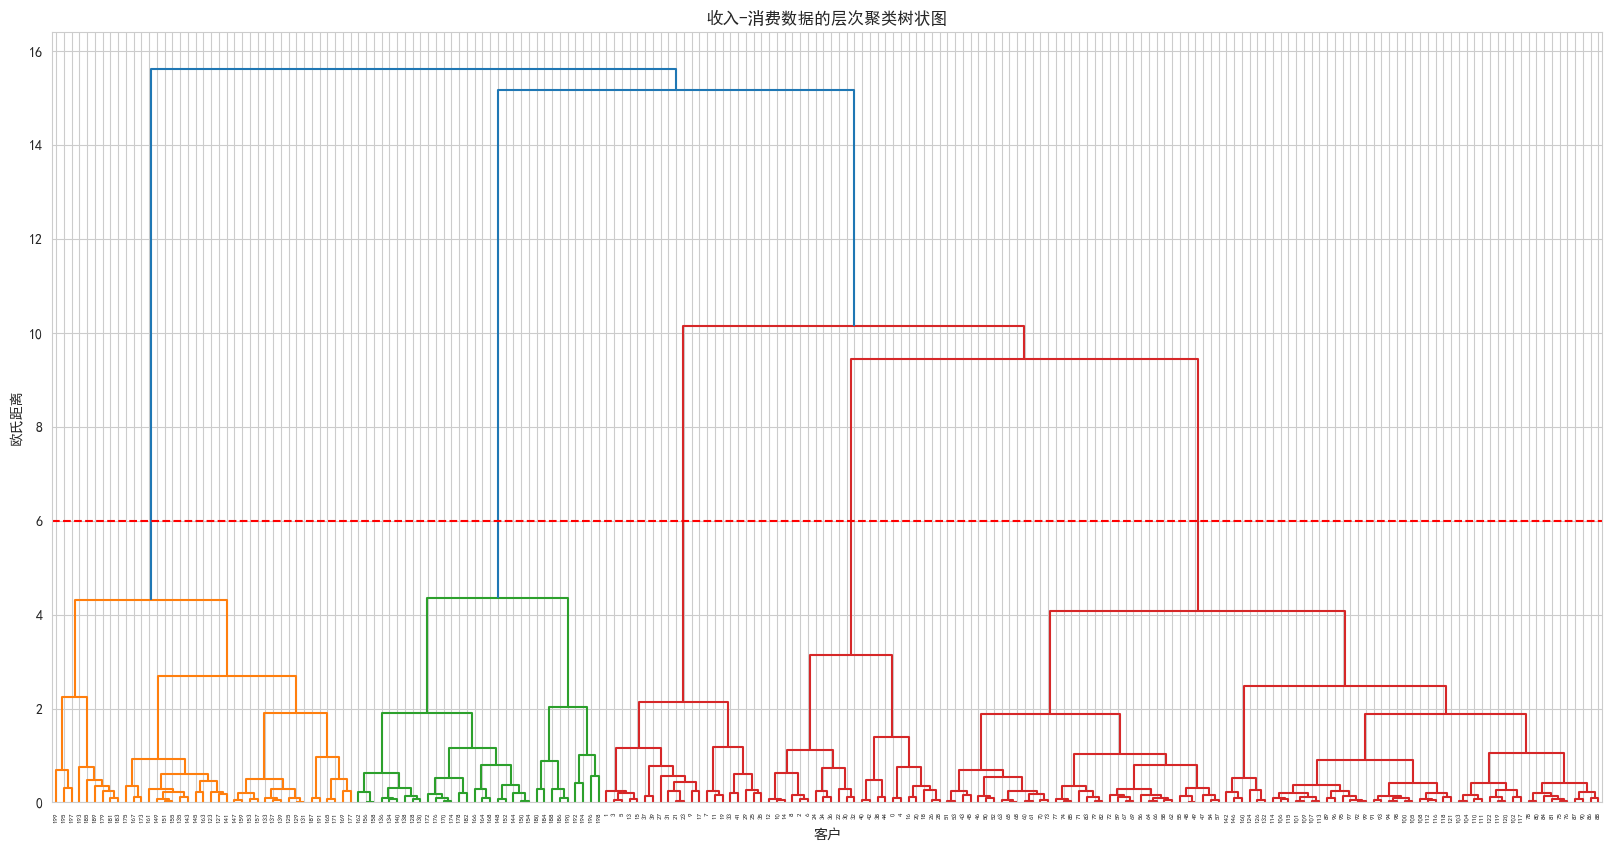

In [19]:
plt.figure(figsize=(20, 10))
dendrogram = sch.dendrogram(sch.linkage(X1_scaled, method='ward'))
plt.title('收入-消费数据的层次聚类树状图')
plt.xlabel('客户')
plt.ylabel('欧氏距离')
plt.axhline(y=6, color='r', linestyle='--') # 示例切分线
plt.show()

**洞察：** 树状图同样支持将收入-消费数据分为 **5 个簇**。如果在高度约为 6 的位置画一条水平线，会穿过五个主要分支。

### 第 6 步：总结

在本项目中，我们使用无监督学习完成了客户细分。

**完成的关键步骤：**

1. **进行了深入 EDA**，使用 2D 和 3D 图从多个角度观察客户数据。
2. **建立了两个细分模型**，分别分析基于收入和基于年龄的客户行为。
3. **使用肘部法则** 选择聚类数量。
4. **引入层次聚类**，并使用树状图验证收入-消费细分结果。
5. **创建数据驱动的客户画像**，把聚类统计结果转化为营销行动建议。

这个项目的核心启发是：聚类通常没有唯一的“正确答案”。不同特征组合会揭示不同业务视角，因此解释能力和算法本身同样重要。

### 提交标准

为了完成本项目，请确保 notebook 包含以下内容：

1. **分析 Gender 与 Spending Score 的关系：** 使用可视化和汇总统计探索性别是否与消费行为存在明显关联。
2. **为聚类进行特征工程：** 基于现有数据构造至少一个新特征，并测试它是否能支持有意义的聚类模型。
3. **选择并解释聚类结果：** 使用肘部法则等方法选择 `k`，可视化聚类结果，并用业务语言解释客户画像。